### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load Dataset

In [2]:
co = pd.read_csv("cab_orders.csv")
cc = pd.read_csv("cabcompanies.csv")
ccs = pd.read_csv("cabcustomers.csv")
cd = pd.read_csv("cabdrivers.csv")
ci = pd.read_csv("cabincidents.csv")

### 3. Dataset Details

In [3]:
co.info()

<class 'pandas.DataFrame'>
RangeIndex: 5040 entries, 0 to 5039
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      5040 non-null   str    
 1   customer_id   4961 non-null   str    
 2   driver_id     4943 non-null   str    
 3   company       4927 non-null   str    
 4   order_date    4731 non-null   str    
 5   distance_km   4877 non-null   float64
 6   price_rs      4736 non-null   str    
 7   tip_rs        3083 non-null   float64
 8   rating        4794 non-null   float64
 9   service_type  4959 non-null   str    
 10  payment_mode  4931 non-null   str    
 11  pickup_city   4955 non-null   str    
dtypes: float64(3), str(9)
memory usage: 472.6 KB


In [4]:
cc.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   company_id        10 non-null     str    
 1   company_name      10 non-null     str    
 2   base_fare_rs      9 non-null      float64
 3   per_km_rate_rs    9 non-null      float64
 4   services_offered  10 non-null     str    
 5   vehicle_types     10 non-null     str    
dtypes: float64(2), str(4)
memory usage: 612.0 bytes


In [5]:
ccs.info()

<class 'pandas.DataFrame'>
RangeIndex: 3025 entries, 0 to 3024
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  3025 non-null   str    
 1   name         2964 non-null   str    
 2   age          2930 non-null   float64
 3   gender       2991 non-null   str    
 4   city         2935 non-null   str    
 5   email        2966 non-null   str    
 6   signup_date  2817 non-null   str    
dtypes: float64(1), str(6)
memory usage: 165.6 KB


In [6]:
cd.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   driver_id         500 non-null    str    
 1   name              493 non-null    str    
 2   age               480 non-null    float64
 3   gender            491 non-null    str    
 4   city              500 non-null    str    
 5   experience_years  484 non-null    float64
 6   company_id        478 non-null    str    
dtypes: float64(2), str(5)
memory usage: 27.5 KB


In [7]:
ci.info()

<class 'pandas.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   incident_id     420 non-null    str    
 1   order_id        420 non-null    str    
 2   incident_type   420 non-null    str    
 3   incident_date   402 non-null    str    
 4   city            420 non-null    str    
 5   severity        420 non-null    str    
 6   fine_amount_rs  381 non-null    float64
 7   description     348 non-null    str    
 8   status          420 non-null    str    
dtypes: float64(1), str(8)
memory usage: 29.7 KB


### 4. Data Cleaning

In [8]:
# Orders Table

In [9]:
co.duplicated().sum()

np.int64(40)

In [10]:
co.drop_duplicates(inplace = True)

In [11]:
co["customer_id"].isnull().sum()

np.int64(78)

In [12]:
# I have instructions to drop colm when customer_id is not present or null.
co.dropna(subset = ["customer_id"], inplace = True)

In [13]:
co["driver_id"].isnull().sum()

np.int64(94)

In [14]:
co["driver_id"] = co["driver_id"].fillna("Unkown")

In [15]:
co["company"].unique()

<StringArray>
[       'blusmart',          'JUGNOO',            'MERU',             'Ola',
            'Uber',    '  BluSmart  ',         'indrive',          'jugnoo',
     'Namma Yatri',         'INDRIVE',     'NAMMA YATRI',        '  Uber  ',
          'Rapido',      '  Rapido  ',            'meru',               nan,
        '  Meru  ',        'BluSmart',         'InDrive',          'Jugnoo',
     '  InDrive  ',            'Meru',            'UBER',            ' Ola',
             'ola',             'OLA',     'namma yatri',        'BLUSMART',
           ' Meru',          'rapido',        ' InDrive',         ' Rapido',
            'uber',    ' Namma Yatri',       ' BluSmart',          'RAPIDO',
           ' Uber',         ' Jugnoo',         '  Ola  ', '  Namma Yatri  ',
      '  Jugnoo  ']
Length: 41, dtype: str

In [16]:
co["company"] = co["company"].str.title()

In [17]:
co["company"] = co["company"].str.strip()

In [18]:
co["company"] = co["company"].fillna("Unknown")

In [19]:
co["order_date"].isnull().sum()

np.int64(296)

In [20]:
co["order_date"] = co["order_date"].replace('00-00-0000',np.nan)

In [21]:
# I have instructions to fill null dates by forward fill
co["order_date"] = co["order_date"].ffill()

In [22]:
co["order_date"] = pd.to_datetime(co["order_date"], format = "mixed")

In [23]:
co["distance_km"].isnull().sum()

np.int64(159)

In [24]:
co["distance_km"] = co["distance_km"].abs()

In [25]:
co["distance_km"].max()

np.float64(1941.01)

In [26]:
co.loc[co["distance_km"] >= 101 , "distance_km"] = co["distance_km"].quantile(0.99)

In [27]:
def distance(value):
    if value < 1:
        return np.nan
    else:
        return value

In [28]:
co["distance_km"] = co["distance_km"].apply(distance)

In [29]:
co["distance_km"] = co["distance_km"].fillna(co["distance_km"].mean())

In [30]:
co["distance_km"] = co["distance_km"].astype(int)

In [31]:
co["price_rs"].isnull().sum()

np.int64(297)

In [32]:
co["price_rs"] = co["price_rs"].astype(str).str.replace(r"Rs","",regex = True)

In [33]:
co["price_rs"] = co["price_rs"].astype(str).str.strip()

In [34]:
 co["price_rs"].min()

'-104.56'

In [35]:
co["price_rs"] = co["price_rs"].fillna(0.1)

In [36]:
co["price_rs"] = co["price_rs"].astype(float)

In [37]:
co["price_rs"] = co["price_rs"].abs()

In [38]:
co["price_rs"].quantile(0.99)

np.float64(372.86)

In [90]:
co.loc[co["price_rs"] > 500, "price_rs"] = co["price_rs"].quantile(0.99)

In [91]:
co["price_rs"].dtype

dtype('float64')

In [92]:
co["price_rs"] = co["price_rs"].replace(0.1,np.nan)

In [93]:
co["price_rs"] = co["price_rs"].fillna(co.groupby("service_type")["price_rs"].transform("mean"))

In [94]:
co[co["price_rs"].isnull()]

,order_id,customer_id,driver_id,company,order_date,distance_km,price_rs,tip_rs,rating,service_type,payment_mode,pickup_city


In [95]:
co["price_rs"] = co["price_rs"].astype(int)

In [96]:
co["tip_rs"].min()

np.int64(0)

In [97]:
co["tip_rs"] = co["tip_rs"].abs()

In [98]:
co["tip_rs"] = co["tip_rs"].fillna(0)

In [99]:
co["tip_rs"] = co["tip_rs"].astype(int)

In [100]:
def rating(value):
    if value < 1 or value > 5:
        return np.nan
    else:
        return value
    

In [101]:
co["rating"] = co["rating"].apply(rating)

In [102]:
co["service_type"].unique()

<StringArray>
['Xl', 'Mini', 'Auto', 'Sedan', 'Prime', 'Bike', 'Suv', 'Pool', 'unknown']
Length: 9, dtype: str

In [103]:
co["service_type"] = co["service_type"].str.title()

In [104]:
co["service_type"] = co["service_type"].str.strip()

In [105]:
co["service_type"] = co["service_type"].fillna("unknown")

In [106]:
co["payment_mode"].unique()

<StringArray>
['Wallet', 'Net Banking', 'Upi', 'Card', 'Cash', 'Unknown']
Length: 6, dtype: str

In [107]:
co["payment_mode"] = co["payment_mode"].str.title()

In [108]:
co["payment_mode"] = co["payment_mode"].str.strip()

In [109]:
co["payment_mode"] = co["payment_mode"].fillna("Unknown")

In [110]:
co["pickup_city"].unique()

<StringArray>
[  'Gurugram',  'Bangalore',     'Mumbai',     'Jaipur',      'Delhi',
  'Faridabad',  'Hyderabad',    'Kolkata',    'Chennai',      'Noida',
  'Ahmedabad',     'Indore',    'Lucknow',    'Unknown',     'Bhopal',
 'Chandigarh',       'Pune']
Length: 17, dtype: str

In [111]:
co["pickup_city"] = co["pickup_city"].str.title()

In [112]:
co["pickup_city"] = co["pickup_city"].str.strip()

In [113]:
co["pickup_city"] = co["pickup_city"].fillna("Unknown")

In [114]:
# Companies Table

In [115]:
cc["company_name"].unique()

<StringArray>
['Ola', 'Uber', 'Rapido', 'Meru', 'Jugnoo', 'Blusmart', 'Indrive',
 'Namma Yatri']
Length: 8, dtype: str

In [116]:
cc["company_name"] = cc["company_name"].str.title().str.strip()

In [117]:
cc["base_fare_rs"] = cc["base_fare_rs"].fillna(cc["base_fare_rs"].mean()).astype(int)

In [118]:
cc["per_km_rate_rs"] = cc["per_km_rate_rs"].fillna(cc["per_km_rate_rs"].mean()).astype(int)

In [119]:
# Customer Table

In [120]:
ccs.duplicated().sum()

np.int64(0)

In [121]:
ccs.drop_duplicates(inplace = True)

In [122]:
ccs["name"] = ccs["name"].str.title().str.strip()

In [123]:
ccs["name"] = ccs["name"].fillna("Unknown")

In [124]:
ccs.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  3000 non-null   str  
 1   name         3000 non-null   str  
 2   age          3000 non-null   int64
 3   gender       3000 non-null   str  
 4   city         3000 non-null   str  
 5   email        2942 non-null   str  
 6   signup_date  3000 non-null   str  
dtypes: int64(1), str(6)
memory usage: 164.2 KB


In [125]:
ccs["age"] = ccs["age"].abs()

In [126]:
ccs.loc[(ccs["age"] > 100) | (ccs["age"] < 18), "age"] = np.nan

In [127]:
ccs["age"] = ccs["age"].fillna(ccs["age"].median()).astype(int)

In [128]:
ccs["gender"].unique()

<StringArray>
['Male', 'Female', 'Other', 'Not Specified']
Length: 4, dtype: str

In [129]:
ccs["gender"] = ccs["gender"].str.title()

In [130]:
ccs["gender"] = ccs["gender"].replace({"M" : "Male",
                       "F" : "Female"})

In [131]:
ccs["gender"] = ccs["gender"].fillna("Not Specified")

In [132]:
ccs["city"] = ccs["city"].str.title().str.strip()

In [133]:
ccs["city"] = ccs["city"].fillna("Unknown")

In [134]:
ccs["email"] = ccs["email"].str.lower()

In [135]:
ccs["email"].str.split("@").str[1].unique()

array(['mail.com', 'gmail.com', 'outlook.com', 'yahoo.com', nan],
      dtype=object)

In [136]:
ccs["signup_date"] = ccs["signup_date"].replace('00-00-0000',np.nan)

In [137]:
ccs["signup_date"] = ccs["signup_date"].ffill()

In [138]:
ccs["signup_date"] = pd.to_datetime(ccs["signup_date"], format = "mixed")

In [139]:
# Drivers Table

In [140]:
cd["name"] = cd["name"].str.title().str.strip()

In [141]:
cd["name"] = cd["name"].fillna("Unknown")

In [142]:
cd["age"] = cd["age"].abs()

In [143]:
cd["age"] = cd["age"].fillna(cd["age"].median())

In [144]:
cd["age"] = cd["age"].astype(int)

In [145]:
cd["age"].quantile()

np.float64(34.0)

In [146]:
cd.loc[cd["age"] < 18, "age"] = cd["age"].quantile()

In [147]:
cd["gender"].unique()

<StringArray>
['Male', 'Female', 'male', 'M', 'F', nan]
Length: 6, dtype: str

In [148]:
cd["gender"] = cd["gender"].str.title()

In [149]:
cd["gender"] = cd["gender"].replace({"M" : "Male",
                      "F" : "Female"})

In [150]:
cd["gender"] = cd["gender"].fillna("Not specified")

In [151]:
cd["city"] = cd["city"].str.strip().str.title()

In [152]:
cd["experience_years"].unique()

array([ 4., 14., 13.,  3.,  1.,  7.,  8.,  6., nan,  0.,  2., 10.,  9.,
       52., 11.,  5., 56., 57., 12., 16., 48., 44., 46., 59.])

In [153]:
cd.loc[cd["experience_years"] > cd["age"], "experience_years"] = np.nan

In [154]:
cd["experience_years"] = cd["experience_years"].fillna(cd["experience_years"].median())

In [155]:
cd["experience_years"] = cd["experience_years"].astype(int)

In [156]:
cd["company_id"] = cd["company_id"].fillna("Unaffiliated")

In [157]:
# Incidents Table

In [158]:
ci["incident_type"].unique()

<StringArray>
[               '  Fight  ',     'Harassment Complaint',
             'Rash Driving',             'overcharging',
             'Overcharging',             'rash driving',
             'RASH DRIVING',     'HARASSMENT COMPLAINT',
        'Vehicle Breakdown',                 'Accident',
                ' Accident',         '  Rash Driving  ',
                    'Fight',    ' Harassment Complaint',
              'misbehavior',                 'ACCIDENT',
          '  Misbehavior  ',             'OVERCHARGING',
                   ' Fight',                    'FIGHT',
            ' Overcharging',                 'accident',
     'harassment complaint',              'Misbehavior',
            ' Rash Driving', '  Harassment Complaint  ',
         '  Overcharging  ',        'VEHICLE BREAKDOWN',
        'vehicle breakdown',              'MISBEHAVIOR',
             '  Accident  ',             ' Misbehavior',
       ' Vehicle Breakdown',                    'fight']
Length: 34, dtype

In [159]:
ci["incident_type"] = ci["incident_type"].str.strip().str.title()

In [160]:
ci["incident_date"] = ci["incident_date"].replace('00-00-0000',np.nan)

In [161]:
ci["incident_date"] = ci["incident_date"].ffill()

In [162]:
ci["incident_date"] = pd.to_datetime(ci["incident_date"],format = "mixed")

In [163]:
ci["city"].unique()

<StringArray>
[     'faridabad',          'Noida',           'Pune',      'Faridabad',
        ' Bhopal',        ' Indore',     '  Jaipur  ',      'BANGALORE',
         'mumbai',       ' Kolkata',        'Lucknow',         'Bhopal',
        'Kolkata',      'hyderabad',           'PUNE',     '  Bhopal  ',
      'Bangalore',         'INDORE',        'LUCKNOW',         'Mumbai',
          'noida',        ' Jaipur',          'Delhi',       'Gurugram',
        ' Mumbai',  '  Bangalore  ',    '  Kolkata  ',         'Jaipur',
     'Chandigarh',     'chandigarh',     ' Hyderabad',           'pune',
      'FARIDABAD',          'DELHI',      'Ahmedabad',         'jaipur',
    '  Chennai  ',         ' Delhi',      ' Gurugram',      'Hyderabad',
 '  Chandigarh  ',        'lucknow',       ' Lucknow',      'ahmedabad',
        'Chennai',          'delhi',      '  Noida  ',         'Indore',
         ' Noida',       'gurugram',        'kolkata',       'GURUGRAM',
  '  Ahmedabad  ',      '  Delhi  ', 

In [164]:
ci["city"] = ci["city"].str.title().str.strip()

In [165]:
ci["severity"].unique()

<StringArray>
[      'MEDIUM',     '  High  ',     'CRITICAL',     'critical',
       'Medium',      '  Low  ',     'Critical',        ' High',
          'Low',         'High',         'high',         ' Low',
      ' Medium', '  Critical  ',   '  Medium  ',          'low',
         'HIGH',          'LOW',       'medium',    ' Critical']
Length: 20, dtype: str

In [166]:
ci["severity"] = ci["severity"].str.strip().str.title()

In [167]:
ci.info()

<class 'pandas.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   incident_id     420 non-null    str           
 1   order_id        420 non-null    str           
 2   incident_type   420 non-null    str           
 3   incident_date   420 non-null    datetime64[us]
 4   city            420 non-null    str           
 5   severity        420 non-null    str           
 6   fine_amount_rs  381 non-null    float64       
 7   description     348 non-null    str           
 8   status          420 non-null    str           
dtypes: datetime64[us](1), float64(1), str(7)
memory usage: 29.7 KB


In [168]:
ci["fine_amount_rs"].min()

np.float64(-525.34)

In [169]:
ci["fine_amount_rs"] = ci["fine_amount_rs"].abs()

In [170]:
ci["fine_amount_rs"].quantile(0.9)

np.float64(4200.79)

In [171]:
ci["fine_amount_rs"] = ci["fine_amount_rs"].fillna(0)

In [172]:
ci["fine_amount_rs"] = ci["fine_amount_rs"].clip(upper = ci["fine_amount_rs"].quantile(0.99)).astype(int)

In [173]:
ci["description"] = ci["description"].fillna("No description")

In [174]:
ci["status"].unique()

<StringArray>
[    'under review',         'resolved',         'Resolved',
          'Pending',     'Under Review',         'RESOLVED',
    ' Under Review',     'UNDER REVIEW',        'dismissed',
       ' Dismissed',        'Dismissed',        'DISMISSED',
         ' Pending', '  Under Review  ',      '  Pending  ',
          'PENDING',        ' Resolved',    '  Dismissed  ',
          'pending',     '  Resolved  ']
Length: 20, dtype: str

In [175]:
ci["status"] = ci["status"].str.strip().str.title()

In [176]:
customer_order_table = pd.merge(co,ccs,on = "customer_id")
Driver_order_table = pd.merge(co,cd, on = "driver_id")
co.rename(columns={"company": "company_name"}, inplace=True)
company_order_table = pd.merge(co,cc,on= "company_name")
incident_order_table = pd.merge(co,ci,on = "order_id")

### Feature Engineering 

In [177]:
co["month"] = co["order_date"].dt.month

In [178]:
ci["fine_status"] = np.where(ci["fine_amount_rs"] > 40000,"Exception","Normal")

In [179]:
ccs["age_category"] = pd.cut(
    ccs["age"],
    bins=[0, 18, 30, 45, 60, 100],
    labels=["Teen", "Young Adult", "Adult", "Middle Age", "Senior"],
    include_lowest=True)

### Business KPI's

In [180]:
# 1) Total revenue earned?
print(f"Rs.{int(co["price_rs"].sum())}")

Rs.739633


In [181]:
# 2) Total rides?
int(co["order_id"].count())

4922

In [182]:
# 3) How many unique customers used the service?
co["customer_id"].nunique()

2438

In [183]:
# 4) How many drivers are available?
int(cd["driver_id"].count())

500

In [184]:
# 5) How many cab companies are operating?
int(cc["company_id"].count())

10

In [185]:
# 6) What is the total distance travelled?
print(f"{co["distance_km"].sum()} (Km)")

42831 (Km)


In [186]:
# 7) What is the average fare per ride?
print(f"Rs.{int(cc["base_fare_rs"].mean())}")

Rs.43


In [187]:
# 8) What is the total tip earned by drivers?
print(f"Rs.{co["tip_rs"].sum()}")

Rs.52937


In [188]:
# 9) What is the average customer rating?
print(f"{int(co["rating"].mean())}★")

3★


In [189]:
# 10) What is the average revenue per order?
print(f"Rs.{round((co["price_rs"].sum())/(co["order_id"].count()))}")

Rs.150


In [190]:
# 11) How many incidents were reported?
int(ci["incident_id"].count())

420

In [191]:
# 12) What is the total fine amount?
print(f"Rs.{int(ci["fine_amount_rs"].sum())}")

Rs.909595


In [192]:
# 13) Which sevice type occurs the most?
co.groupby("service_type")["customer_id"].count().sort_values(ascending = False).head(1)

service_type
Sedan    640
Name: customer_id, dtype: int64

In [193]:
# 14) What is the average driver experience?
print(f"{round(cd["experience_years"].mean())} Years")

6 Years


In [194]:
# 15) What is the average customer age?
print(f"{round(ccs["age"].mean())} Years")

33 Years


In [195]:
# 16) How many cities are served?
print(f"{co["pickup_city"].nunique()} City")

17 City


In [196]:
# 17) How many service types are used?
print(f"{co["service_type"].nunique()} Service")

9 Service


In [197]:
# 18) Which payment mode is used the most?
co.groupby("payment_mode")["customer_id"].count().sort_values(ascending = False).head(1)

payment_mode
Net Banking    992
Name: customer_id, dtype: int64

In [198]:
# 19) Which company receives the most bookings?
co.groupby("company_name")["order_id"].count().sort_values().tail(1)

company_name
Rapido    639
Name: order_id, dtype: int64

In [199]:
# 20) What percentage of rides are rated 4★ or above?
print(f"{round((co["rating"] >= 4).sum()*100/(co["rating"].count()))}%")

41%


In [200]:
# 21) Incident Rate by total order 
print(f"{round((ci["order_id"].count()*100/co["order_id"].count()))}%")

9%


In [201]:
# 22) Repeater customer rate in %
mk = co.groupby("customer_id")["order_id"].count()
print(f"{round(((mk >= 2).sum())*100/(mk.count()))}%")

58%


In [202]:
# 23) Top Driver with highest rating
co.groupby("driver_id")["rating"].mean().sort_values(ascending = False).round(1).head(1)

driver_id
DRV0235    4.7
Name: rating, dtype: float64

In [203]:
# 24) Top company with highest revenue
co.groupby("company_name")["price_rs"].sum().sort_values(ascending = False).head(1)

company_name
Rapido    95331
Name: price_rs, dtype: int64

In [204]:
# 25) Total Incident
int(ci["incident_id"].count())

420

In [205]:
# 26) Average Incident Fine
print(f"Rs.{int(ci["fine_amount_rs"].mean())}")

Rs.2165


In [206]:
# 27) City with Highest Customer
ccs.groupby("city")["customer_id"].count().sort_values(ascending = False).head(1)

city
Chandigarh    199
Name: customer_id, dtype: int64

In [207]:
# 28) City with HIghest Driver
cd.groupby("city")["driver_id"].count().sort_values(ascending = False).head(1)

city
Mumbai    41
Name: driver_id, dtype: int64

In [208]:
# 29) Average completed by drivers 
round(co["order_id"].count()/cd["driver_id"].count())

10

In [209]:
# 30) Driver with Highest Rides
co.groupby("driver_id")["order_id"].count().sort_values(ascending = False).head(2).tail(1)

driver_id
DRV0438    21
Name: order_id, dtype: int64

### Visualization analysis 

In [210]:
# Small Automation 
def detail(title,xlabel,ylabel):
    plt.title(title,fontsize = 20, fontweight = "bold", color = "green")
    plt.xlabel(xlabel,color = "green", fontweight = "bold")
    plt.ylabel(ylabel,color = "green", fontweight = "bold")
    plt.show()

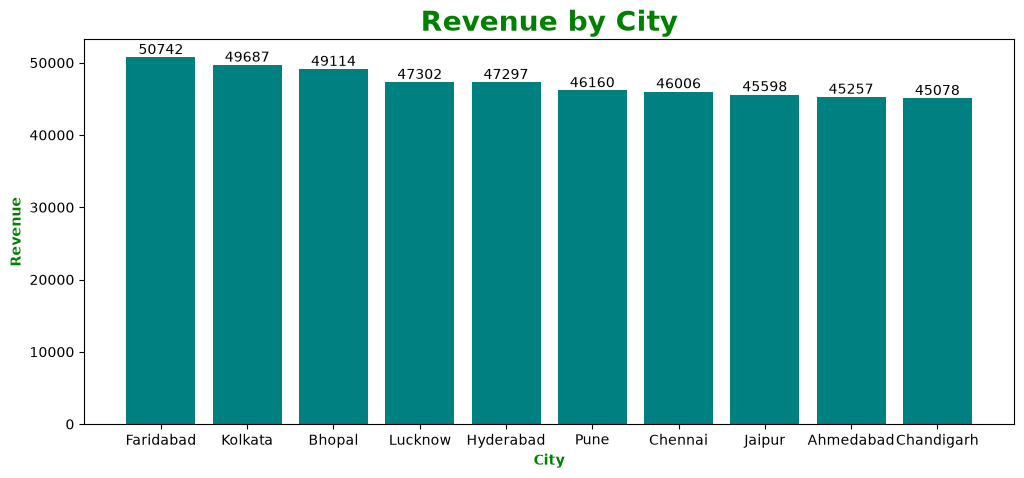

In [211]:
# Top 10 pickup city
city_revenue = co.groupby("pickup_city")["price_rs"].sum().sort_values(ascending = False).head(10)
plt.figure(figsize = (12,5))

bars = plt.bar(city_revenue.index, city_revenue.values, color = "teal")
plt.bar_label(bars)
detail("Revenue by City","City","Revenue")

##### This chart was created to compare the total revenue generated from different pickup cities. It helps identify which locations contribute the most to the business and which ones require improvement. By comparing city-wise revenue, stakeholders can easily recognize high-performing markets and plan location-specific strategies. This visualization supports better resource allocation and business expansion decisions.

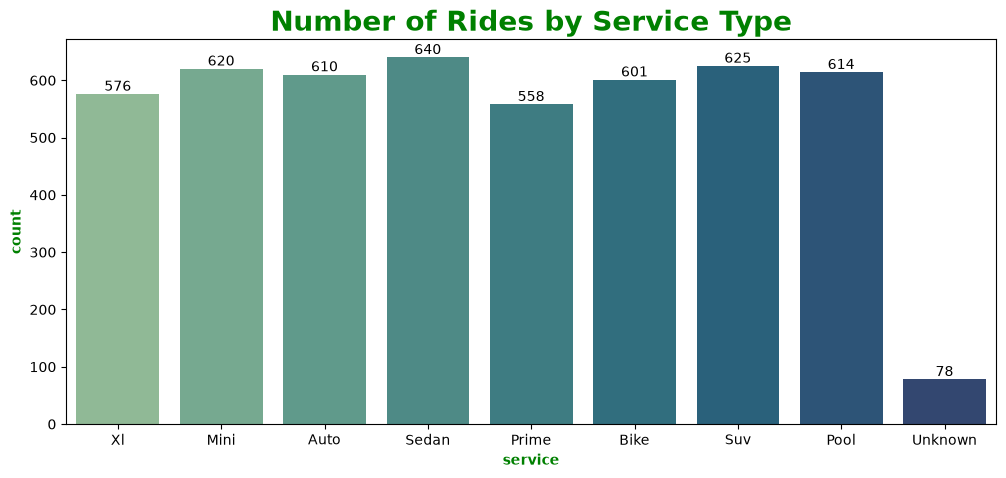

In [212]:
plt.figure(figsize=(12,5))

ax = sns.countplot(data=co, x="service_type",hue = "service_type",palette = "crest")

for container in ax.containers:
    ax.bar_label(container)
detail("Number of Rides by Service Type","service","count")

##### This chart shows how ride demand is distributed across different service types. It is useful for understanding customer preferences and the popularity of each service. The visualization highlights which services are most frequently used. This information helps the company optimize fleet availability and improve operational planning.

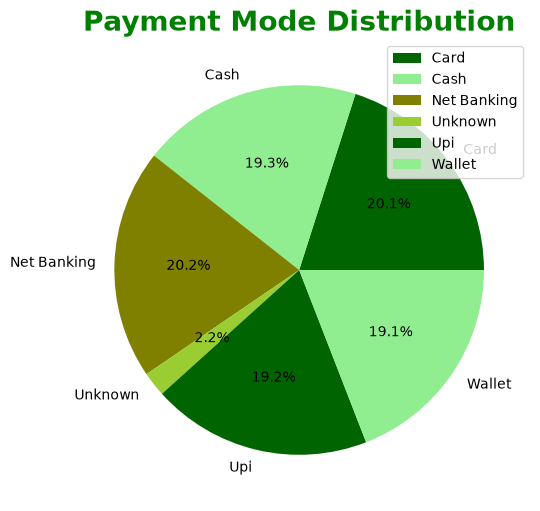

In [213]:
payment_distribution = co.groupby("payment_mode")["order_id"].count()
plt.figure(figsize = (6,6))

plt.pie(payment_distribution.values, labels = payment_distribution.index,autopct="%1.1f%%",colors = ["darkgreen","lightgreen","olive","yellowgreen"])
plt.legend()
plt.title("Payment Mode Distribution", color = "green", fontsize = 20, fontweight = "bold")
plt.show()

##### This pie chart illustrates the proportion of rides completed using each payment method. It helps understand customer payment preferences and the adoption of digital versus cash transactions. The chart quickly shows which payment modes dominate the business. These insights can guide payment-related offers and improve customer convenience.

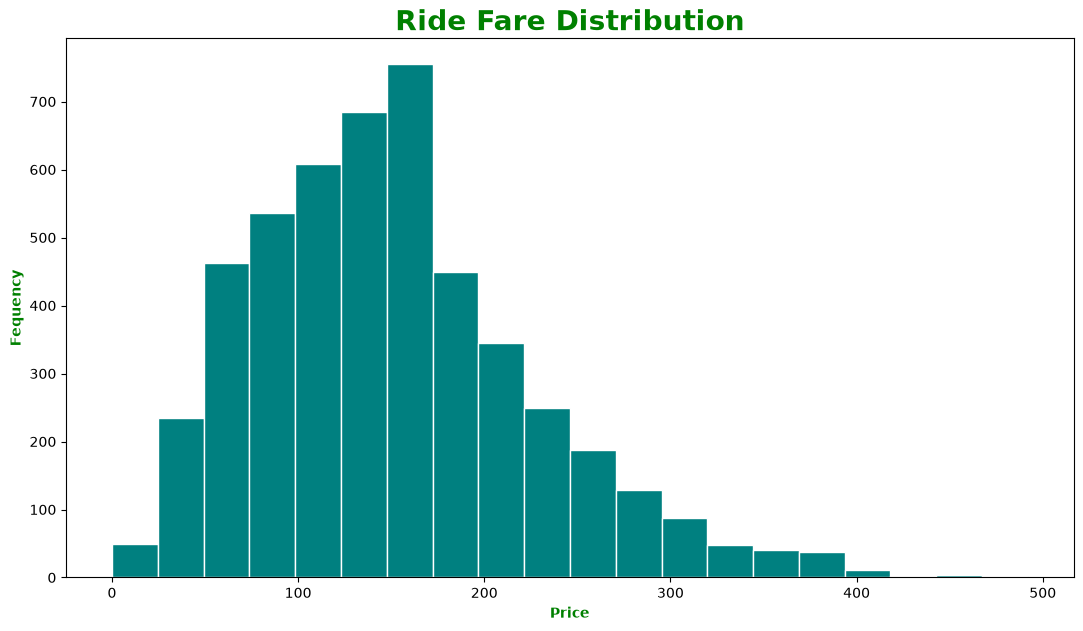

In [214]:
plt.figure(figsize = (13,7))
plt.hist(co["price_rs"], bins = 20, color = "teal", edgecolor = "white")
detail("Ride Fare Distribution","Price","Fequency")

##### This histogram displays how ride fares are distributed across all completed rides. It helps identify the most common fare range and the spread of ride prices. The chart also reveals whether extremely high or low fares exist in the dataset. This analysis is useful for pricing strategy and detecting unusual fare patterns.

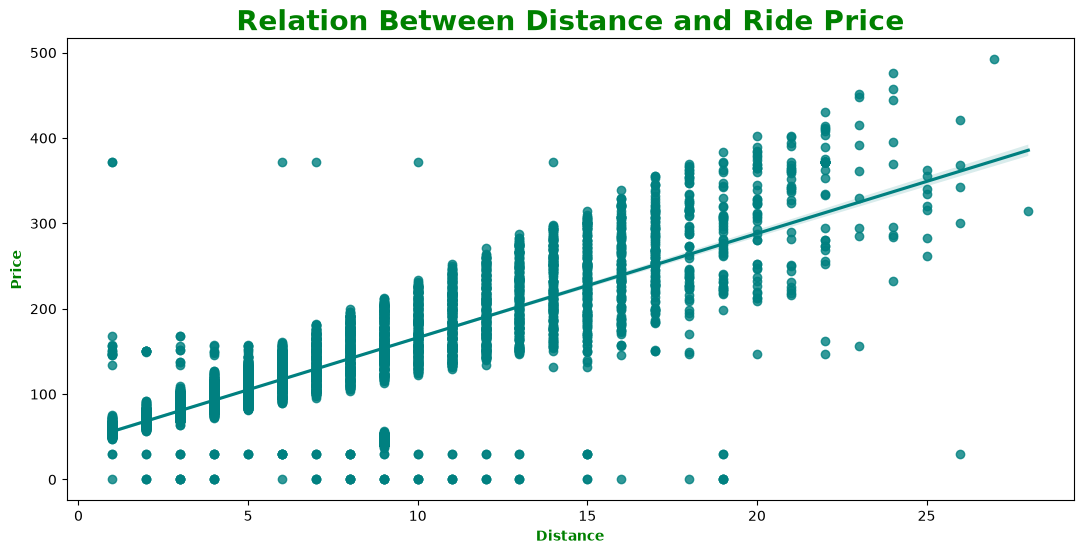

In [215]:
plt.figure(figsize=(13,6))

sns.regplot(data = co, x = co["distance_km"], y = co["price_rs"], scatter = True
           , color = "teal")
detail("Relation Between Distance and Ride Price", "Distance", "Price")

##### This scatter plot with a regression line examines the relationship between travel distance and ride price. It helps determine whether fares increase consistently as distance increases. The trend line makes it easy to observe the overall correlation between these variables. This analysis validates the pricing structure and identifies possible pricing anomalies.

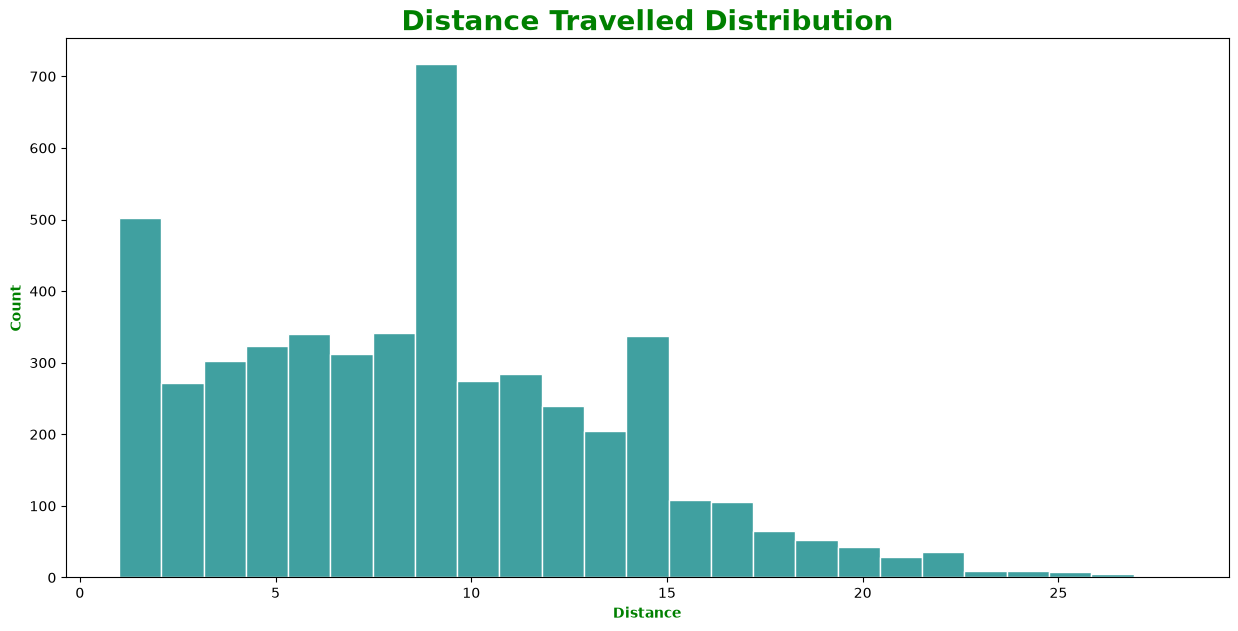

In [216]:
plt.figure(figsize =(15,7))

sns.histplot(data=co, x= co["distance_km"], bins = 25,color = "teal",edgecolor = "white")

detail("Distance Travelled Distribution", "Distance", "Count")

##### This histogram shows how far customers typically travel during their rides. It helps identify the most common trip distances and overall travel patterns. The distribution also reveals whether long-distance rides are frequent or rare. These insights assist in demand forecasting and fleet management.

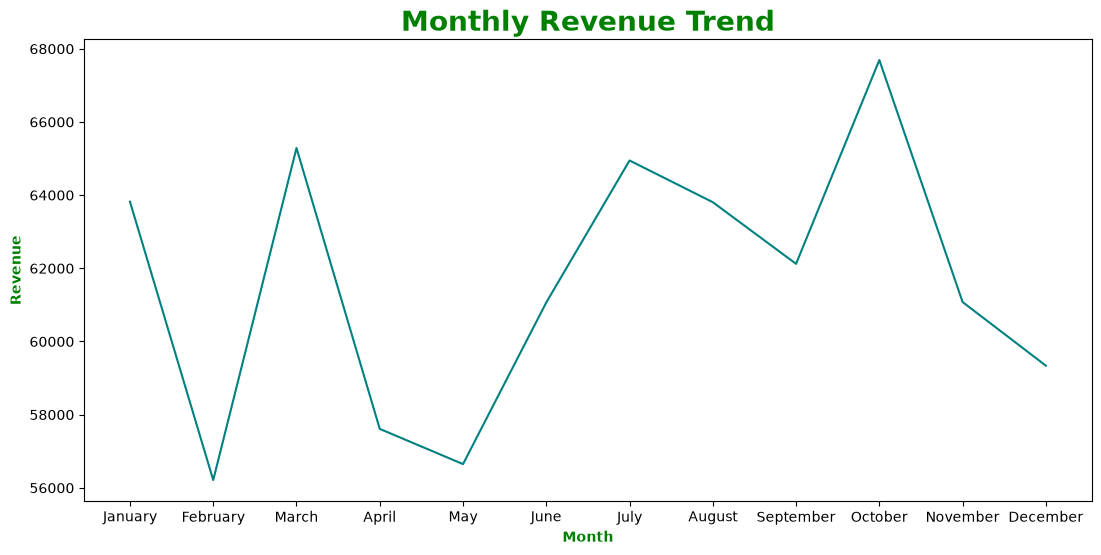

In [217]:
month_revenue = co.groupby("month")["price_rs"].sum()
month_revenue.index = pd.to_datetime(month_revenue.index, format = "%m").month_name()
plt.figure(figsize = (13,6))

plt.plot(month_revenue.index,month_revenue.values, color = "teal")

detail("Monthly Revenue Trend","Month","Revenue")

##### This line chart tracks total revenue across different months. It is useful for identifying seasonal trends, growth patterns, and revenue fluctuations over time. The visualization makes it easy to compare business performance month by month. This helps management evaluate growth and plan future business strategies.

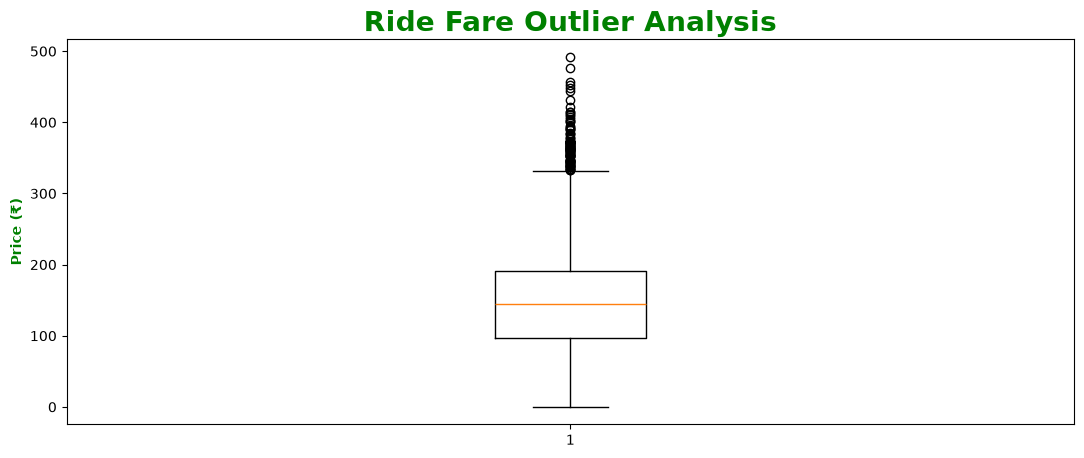

In [218]:
plt.figure(figsize=(13,5))

plt.boxplot(co["price_rs"], )

plt.title("Ride Fare Outlier Analysis", fontweight = "bold", color = "green", fontsize = 20)
plt.ylabel("Price (₹)", fontweight = "bold", color = "green" )
plt.show()

##### This box plot was created to detect unusually high or low ride fares in the dataset. It helps identify outliers that may result from premium rides, pricing errors, or exceptional cases. The chart provides a quick summary of the fare distribution and variability. This analysis improves data quality and supports accurate business reporting.

Text(0.5, 1.0, 'Gender Count')

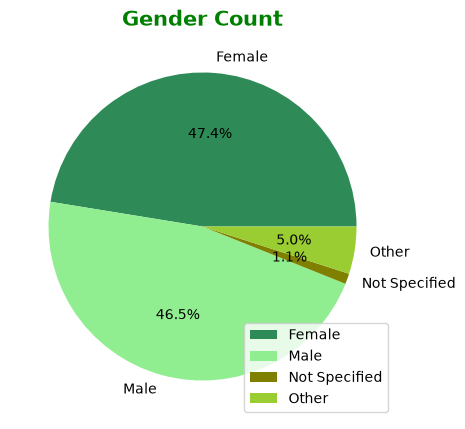

In [219]:
gender_count = ccs.groupby("gender")["customer_id"].count()
plt.figure(figsize = (7,5))

plt.pie(gender_count.values, labels = gender_count.index, autopct = "%1.1f%%", colors = ["seagreen","lightgreen","olive","yellowgreen"])
plt.legend()

plt.title("Gender Count", fontsize = 15, fontweight = "bold", color = "green")

##### This pie chart represents the distribution of customers based on gender. It helps understand the demographic composition of the customer base. The visualization clearly shows the proportion of each gender category. These insights can support targeted marketing and customer engagement strategies.

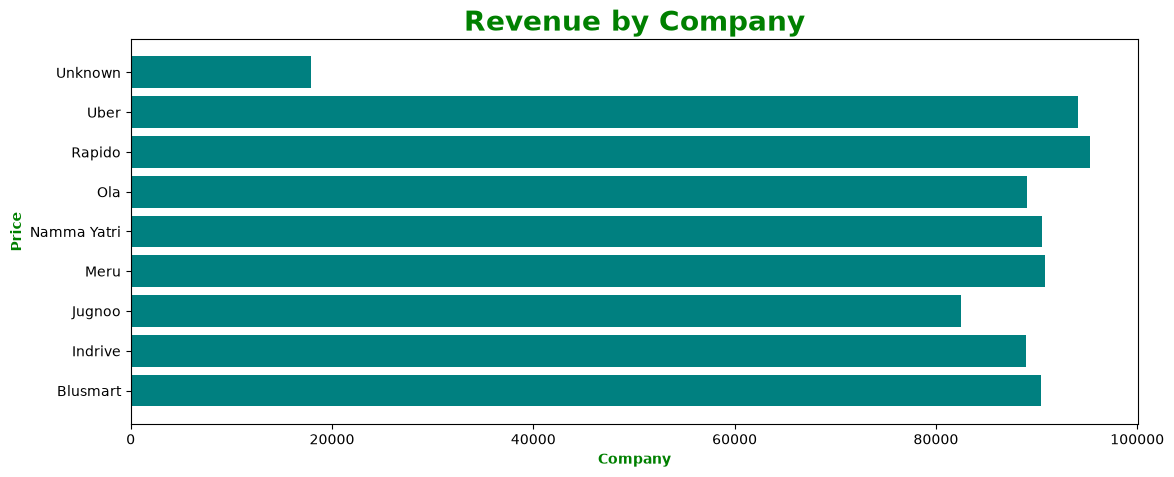

In [220]:
company_rev = co.groupby("company_name")["price_rs"].sum()
plt.figure(figsize = (13,5))

plt.barh(company_rev.index,company_rev.values, color = "teal")
detail("Revenue by Company","Company","Price")

##### This horizontal bar chart compares the revenue generated by different cab companies. It helps identify which company contributes the highest share of revenue. The comparison highlights differences in business performance across companies. These insights support partnership evaluation and performance monitoring.

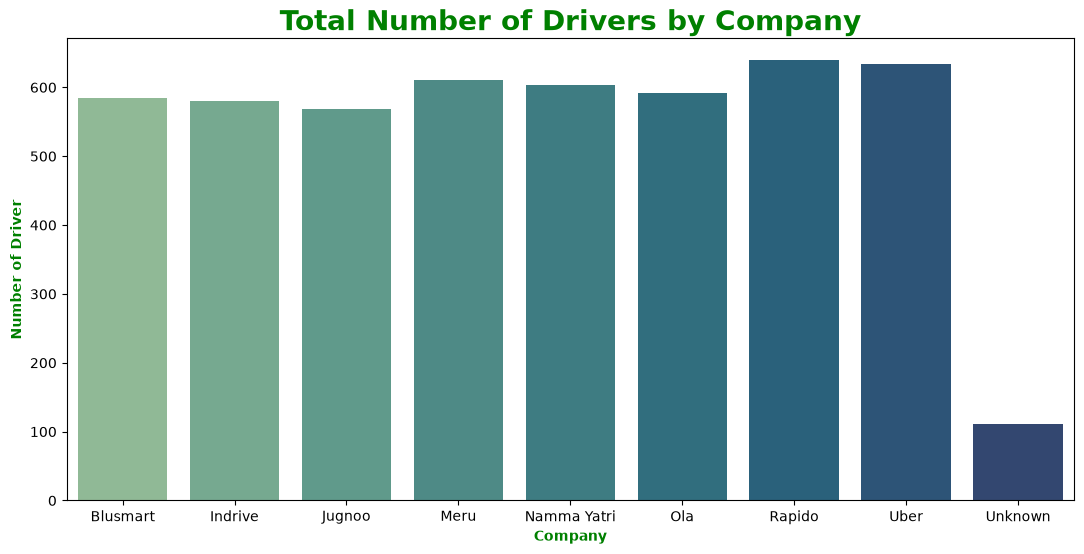

In [221]:
driver_count = co.groupby("company_name")["driver_id"].count().reset_index()

plt.figure(figsize = (13,6))
sns.barplot(
    data=driver_count,
    x="company_name",
    y="driver_id", 
    hue = "company_name",
    palette ="crest")
detail("Total Number of Drivers by Company","Company","Number of Driver")

plt.show()

##### This chart compares the number of drivers working with each cab company. It helps evaluate the operational capacity of different companies. The visualization makes it easy to identify companies with larger or smaller driver networks. This information supports workforce planning and operational analysis.

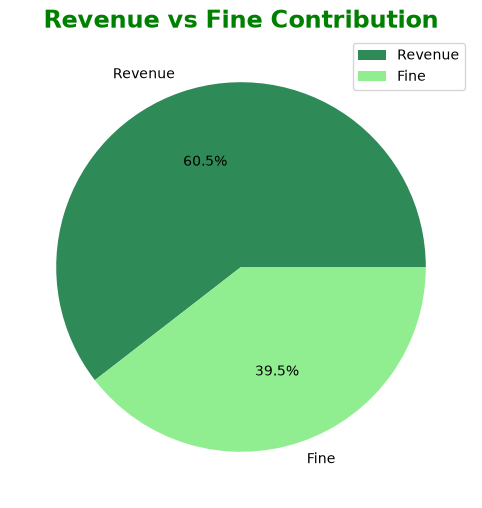

In [222]:
normal_fine = ci[ci["fine_status"]  == "Normal"]
revenue = co["price_rs"].sum()
fine = normal_fine["fine_amount_rs"].sum()
value = [revenue,fine]
labels = ["Revenue","Fine"]
colors = ["seagreen","lightgreen"]

plt.figure(figsize = (8,6))
plt.pie(value,labels = labels, colors = colors, autopct = "%1.1f%%")
plt.legend()
plt.title("Revenue vs Fine Contribution", color = "green", fontsize = 17, fontweight = "bold")
plt.show()

##### This pie chart compares the company's total revenue with the total amount collected as fines. It provides a quick overview of the financial impact of penalties relative to earnings. The comparison shows whether fines represent a significant portion of the business. This insight helps assess operational efficiency and compliance.

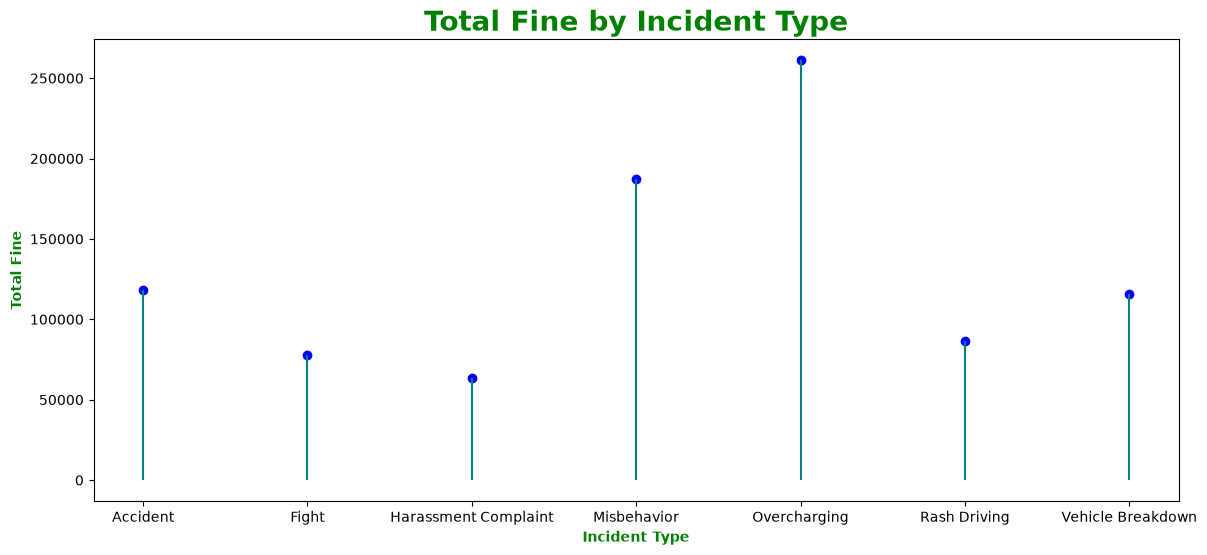

In [223]:
incident = ci.groupby("incident_type")["fine_amount_rs"].sum()
plt.figure(figsize = (14,6))

plt.vlines(x=incident.index,ymin = 0, ymax=incident.values, color = "teal")
plt.scatter(incident.index,incident.values, color = "blue")

detail("Total Fine by Incident Type","Incident Type","Total Fine")

##### This lollipop chart displays the total fine amount associated with each incident type. It helps identify which incidents result in the highest financial penalties. The visualization makes comparisons simple while keeping the chart clean and easy to read. These insights help prioritize safety measures and reduce costly incidents.

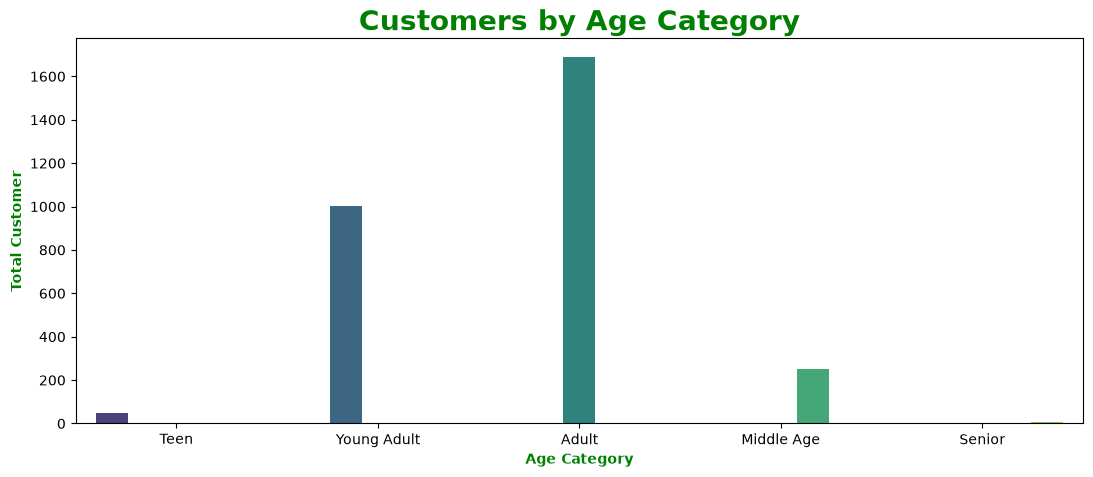

In [224]:
revenue = (ccs.groupby("age_category")["customer_id"]
           .count()
           .reset_index())

plt.figure(figsize=(13,5))

sns.barplot(
    data=revenue,
    x="age_category",
    y="customer_id",
    hue = "age_category",
    palette="viridis",
    legend = False
)
detail("Customers by Age Category","Age Category","Total Customer")


##### This bar chart shows the number of customers in each age category. It helps identify which age groups contribute the largest customer base. The comparison provides valuable demographic insights into customer behavior. This information can be used to design age-specific marketing campaigns and improve business decisions.

## Insights 
•	The company generated ₹7, 39,633 in total revenue, reflecting the overall earnings from all completed rides during the analysis period.

•	A total of 4,922 rides were completed, indicating strong customer demand and platform activity.

•	The platform served 2,438 unique customers, showing its customer reach and market penetration.

•	The company has 500 registered drivers, providing sufficient fleet capacity to meet customer demand.

•	10 Cab companies are operating on the platform, creating a competitive and diverse service network.

•	Drivers collectively covered 42,831 km, demonstrating the operational scale of the business.

•	The average base fare per ride was ₹ 43, representing the typical cost of a trip before additional charges.

•	Drivers earned ₹52,937 in customer tips, reflecting customer satisfaction and service quality.

•	The platform maintained an average customer rating of 3★, indicating the overall service experience.

•	Each completed ride generated an average revenue of ₹150, helping measure revenue efficiency.

•	A total of 420 incidents were reported, highlighting the need for continuous monitoring of ride safety and service quality.

•	The company incurred fines worth ₹4, 83,129, representing the financial impact of reported incidents and policy violations.

•	Sedan was the most preferred service type, receiving the highest number of bookings among all categories.

•	Drivers have an average experience of 6 years, indicating the overall expertise of the workforce.

•	The average customer age is 33 years, providing insights into the primary customer demographic.

•	The platform operates across 17 cities, demonstrating its geographical coverage.

•	Customers can choose from 9 different service types, offering flexibility for various travel needs.

•	Net Banking is the most frequently used payment method, suggesting customer preference for this payment option.

•	Rapido received the highest number of ride bookings, making it the most preferred cab company on the platform.

•	41% of all rides received ratings of 4★ or higher, indicating a high level of customer satisfaction.

•	The incident rate is 9%, meaning approximately 9 incidents occurred for every 100 rides.

•	58 % of customers booked more than one ride, showing customer loyalty and repeat business.

•	Driver DRVO235 achieved the highest average rating of 4.7★, demonstrating outstanding service quality.

•	Rapido generated the highest revenue of ₹95,331, making it the top-performing company financially.

•	Chandigarh has the highest customer base with 199 registered customers, indicating strong demand and a large user presence in this city.

•	Mumbai has the highest number of drivers (41), suggesting greater driver availability to meet high ride demand and reduce waiting time.

•	On average, each driver completed 10 rides, reflecting a balanced workload and healthy driver utilization across the platform.

•	Driver DRV0438 completed 21 rides, making them the second most active driver and highlighting consistently high service activity.



In [225]:
!pip install sqlalchemy pymysql


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [226]:
from sqlalchemy import create_engine

In [227]:
# engine = create_engine("mysql+pymysql://root:MANDAL 2000@localhost/file")

In [228]:
# co.to_sql(
#     name = "orders",
#     con = engine,
#     if_exists = "replace",
#     index = False)

In [229]:
# cc.to_sql(
#     name = "company",
#     con = engine,
#     if_exists = "replace",
#     index = False)

In [230]:
# ccs.to_sql(
#     name = "customer",
#     con = engine,
#     if_exists = "replace",
#     index = False)

In [231]:
# cd.to_sql(
#     name = "driver",
#     con = engine,
#     if_exists = "replace",
#     index = False)

In [232]:
# ci.to_sql(
#     name = "incident",
#     con = engine,
#     if_exists = "replace",
#     index = False)

#### Machine Learning

In [235]:
import sklearn
print(sklearn.__version__)

1.9.0


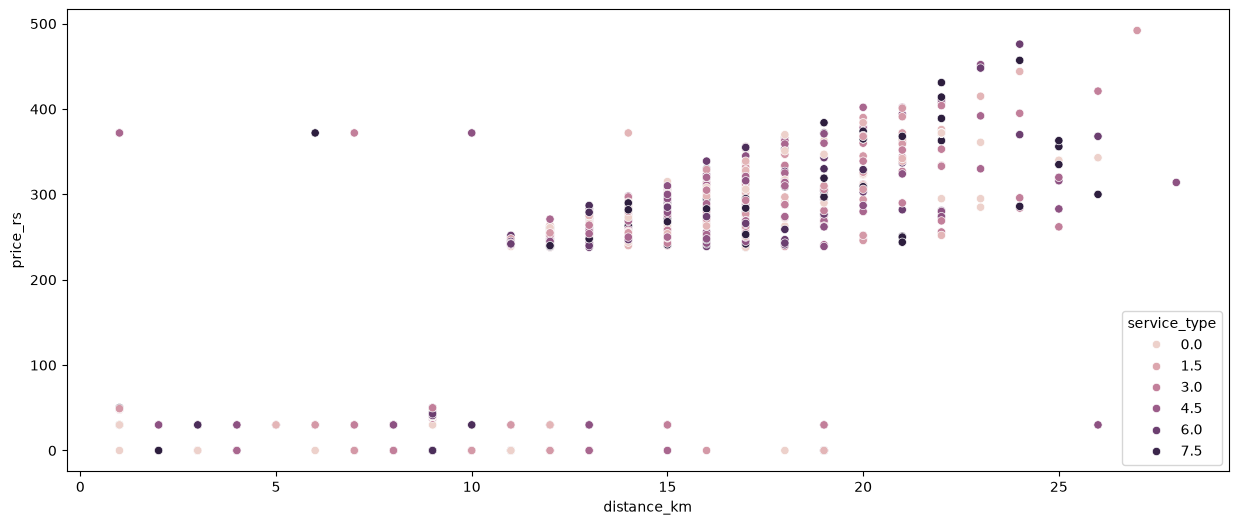

In [254]:
plt.figure(figsize =(15,6))
sns.scatterplot(x = "distance_km", y="price_rs",data=co_price, hue = "service_type")
plt.show()

In [255]:
co["price_rs"].describe

<bound method NDFrame.describe of 0       150
1        73
2        71
3        30
4        81
       ... 
5035    145
5036    116
5037    150
5038    160
5039     61
Name: price_rs, Length: 4922, dtype: int64>

In [256]:
Q25 = 97
Q75 = 191
IRQ = Q25 - Q75 

Min = Q25 - 1.5*IRQ
Max = Q75 + 1.5*IRQ

In [257]:
co_price = co[(co["price_rs"] >= Min) | (co["price_rs"] <= Max)]

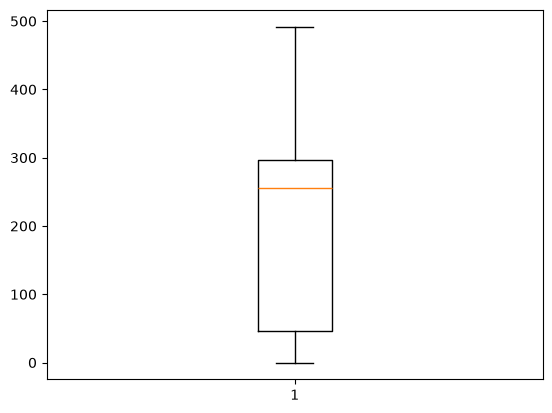

In [258]:
plt.boxplot(co_price["price_rs"])
plt.show()

In [259]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
co_price["company_name"] = oe.fit_transform(co_price[["company_name"]])

In [260]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
co_price["service_type"] = oe.fit_transform(co_price[["service_type"]])

In [261]:
x = co_price[["company_name","distance_km","service_type"]]
y = co_price["price_rs"]

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2, random_state = 20)

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.86,19.94,-0.68]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['company_name','distance_km','service_type']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-68.21
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [262]:
lr.predict([[5,8,5]])

C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([92.22943053])

In [263]:
lr.score(x_test,y_test)*100

70.07108546421964

In [264]:
from sklearn.linear_model import LinearRegression

lrr = LinearRegression()

lrr.fit(x_train,y_train)
lrr.predict([[1,9,5]])

C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([108.73157146])

In [265]:
lrr.score(x_test,y_test)*100

70.07108546421964

In [266]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=20)

rf.fit(x_train,y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",20
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [267]:
rf.predict([[1,15,5]])

C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([292.22533333])

In [268]:
rf.score(x_test,y_test)*100

79.82330117216867

In [269]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

p = cross_val_score(rf,x,y,cv= KFold(n_splits = 5))

p*100

array([61.05849036, 77.53128368, 73.94516318, 67.24732446, 74.36650006])

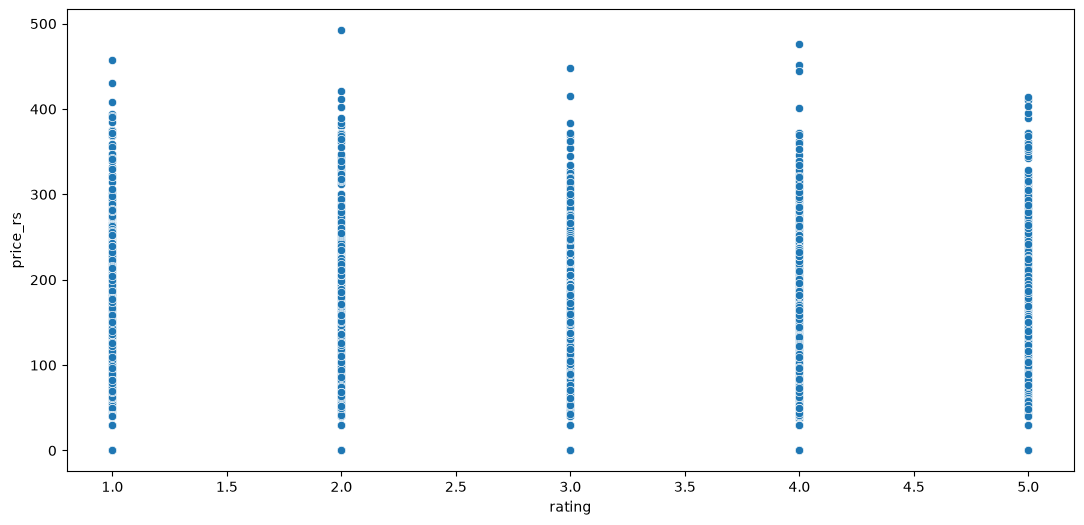

In [270]:
plt.figure(figsize = (13,6))
sns.scatterplot(x="rating",y="price_rs",data = co)
plt.show()

<Axes: xlabel='service_type', ylabel='distance_km'>

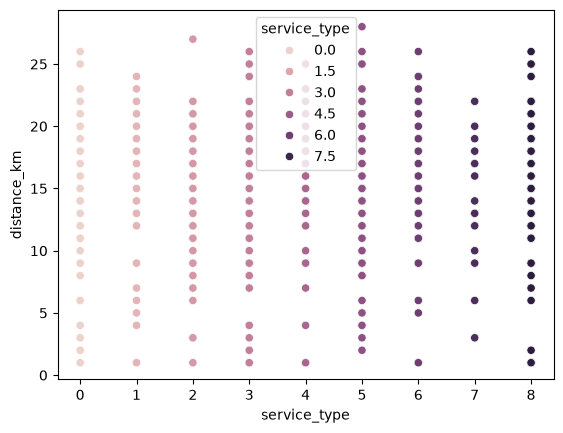

In [271]:
sns.scatterplot(x="service_type",y="distance_km",data=co_price, hue = "service_type")